# Homework Classic Machine Learning (50 points)

In this Homework, we will try to classify observations of space to be either stars, galaxies or quasars based on the RD14 from the Sloan Digital Sky Survey  (SDSS). The Sloan Digital Sky Survey is a project which offers public data of space observations. Observations have been made since 1998 and have been made accessible to everyone who is interested. 

http://www.sdss.org/
![alt text](http://www.fingerprintdigitalmedia.com/wp-content/uploads/2014/08/sdss1.jpg)

For this purpose a special 2.5 m diameter telescope was built at the Apache Point Observatory in New Mexico, USA. The telescope uses a camera of 30 CCD-Chips with 2048x2048 image points each. The chips are ordered in 5 rows with 6 chips in each row. Each row observes the space through different optical filters (u, g, r, i, z) at wavelengths of approximately 354, 476, 628, 769, 925 nm.


In this homework we will train several classifier to predict the class of a celestial object based on the observations (features). We will practice data prep, dimensionality reduction, model design and training, model comparison, and feature importance selection.

### Importing Libraries

In [1]:
# (added a few extra here as needed)

# general
import numpy as np
import pandas as pd
import warnings

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# sklearn packages
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn import metrics

# other
warnings.filterwarnings("ignore", category=DeprecationWarning)
%matplotlib inline


## 1. Data Preparation (20 points)

We follow the following steps:
* read (1 point)
* clean (3 points)
* correlate (4 points)
* explore, spread of values (3 points)
* dimensionality reduction (9 points)


In [2]:
# download data (commented out for now to avoid accidentaly re-running)
#!wget "https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/refs/heads/main/data/Skyserver_SQL2_27_2018 6_51_39 PM.csv"


### 1.1 Data read
Read the pandas fata frame from the csv file "Skyserver_SQL2_27_2018 6_51_39 PM.csv" and skip the first row.

**Task: read pandas data frame (1 point)**

Save a copy of the data frame just in case.

In [3]:
# The instructions say "skip the first row" but the first row is the header row, so I'm going to skip the second row instead.
df = pd.read_csv("Skyserver_SQL2_27_2018 6_51_39 PM.csv", skiprows=[1])

# save a copy of the df (backup)
df_backup_initial = df.copy()

**Description of the data fields**

* objid = Object Identifier, self explanatory.
* ra = J2000 Right Ascension (r-band). Angular that is measured eastward along the celestial equator from the Sun at the March equinox to the hour circle of the point above the earth in question.   https://en.wikipedia.org/wiki/Right_ascension
* dec = J2000 Declination (r-band). Angle that is measured north or south of the celestial equator, along the hour circle passing through the point in question. https://en.wikipedia.org/wiki/Declination



The Gunn astronomic magnitude system. u, g, r, i, z represent the response of the 5 bands of the telescope.

Further Information: http://astroweb.case.edu/ssm/ASTR620/mags.html 
* u = better of DeV/Exp magnitude fit
* g = better of DeV/Exp magnitude fit
* r = better of DeV/Exp magnitude fit
* i = better of DeV/Exp magnitude fit
* z = better of DeV/Exp magnitude fit




Run, rerun, camcol and field are features which describe a field within an image taken by the SDSS. A field is basically a part of the entire image corresponding to 2048 by 1489 pixels. 
* run = Run Number, which identifies the specific scan. 
* rereun = Rerun Number, which specifies how the image was processed.
* camcol = Camera column, a number from 1 to 6, identifying the scanline within the run.
* field = Field number, which typically starts at 11 (after an initial rampup time), and can be as large as 800 for particularly long runs.
* specobjid = Object Identifier
* class = object class (galaxy, star or quasar object): The class identifies an object to be either a galaxy, star or quasar. This will be the response variable which we will be trying to predict.

* redshift = Final Redshift: In physics, **redshift** happens when light or other electromagnetic radiation from an object is increased in wavelength, or shifted to the red end of the spectrum. 

* plate = plate number: Each spectroscopic exposure employs a large, thin, circular metal **plate** that positions optical fibers via holes drilled at the locations of the images in the telescope focal plane. These fibers then feed into the spectrographs. Each plate has a unique serial number, which is called plate in views such as SpecObj in the CAS.

* mjd = MJD of observation, **Modified Julian Date**, used to indicate the date that a given piece of SDSS data (image or spectrum) was taken.
* fiberid = fiber ID. The SDSS spectrograph uses optical fibers to direct the light at the focal plane from individual objects to the slithead. Each object is assigned a corresponding **fiberID**. 

**Further information on SDSS images and their attributes:** 

http://www.sdss3.org/dr9/imaging/imaging_basics.php

http://www.sdss3.org/dr8/glossary.php

### 1.2 Data Cleaning 

Basic stats about our dataset. 

**Task: Provide basic infor for the pandas dataframe head (0.5 point)**

In [4]:
#  Task: Provide basic info from the pandas dataframe head (0.5 point) (fixed some typos in the question)
print(df.head())

#it looks to me like the rerun is all the same - this line confirms
print('rerun unqiue values: '+str(df['rerun'].unique()))

# What about run? - this line confirms we have different runs
print('run unqiue values: '+str(df['run'].unique()))

          objid          ra       dec         u         g         r         i  \
0  1.237650e+18  183.598370  0.135285  18.66280  17.21449  16.67637  16.48922   
1  1.237650e+18  183.680207  0.126185  19.38298  18.19169  17.47428  17.08732   
2  1.237650e+18  183.870529  0.049911  17.76536  16.60272  16.16116  15.98233   
3  1.237650e+18  183.883288  0.102557  17.55025  16.26342  16.43869  16.55492   
4  1.237650e+18  183.847174  0.173694  19.43133  18.46779  18.16451  18.01475   

          z  run  rerun  camcol  field     specobjid   class  redshift  plate  \
0  16.39150  752    301       4    267  3.638140e+17    STAR -0.000055    323   
1  16.80125  752    301       4    268  3.232740e+17  GALAXY  0.123111    287   
2  15.90438  752    301       4    269  3.722370e+18    STAR -0.000111   3306   
3  16.61326  752    301       4    269  3.722370e+18    STAR  0.000590   3306   
4  18.04155  752    301       4    269  3.649550e+17    STAR  0.000315    324   

     mjd  fiberid  
0  516

**Task: Find the data types of the database (floats, string, etc etc) using the ``info()`` function (0.5 point).**

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      9999 non-null   float64
 1   ra         9999 non-null   float64
 2   dec        9999 non-null   float64
 3   u          9999 non-null   float64
 4   g          9999 non-null   float64
 5   r          9999 non-null   float64
 6   i          9999 non-null   float64
 7   z          9999 non-null   float64
 8   run        9999 non-null   int64  
 9   rerun      9999 non-null   int64  
 10  camcol     9999 non-null   int64  
 11  field      9999 non-null   int64  
 12  specobjid  9999 non-null   float64
 13  class      9999 non-null   object 
 14  redshift   9999 non-null   float64
 15  plate      9999 non-null   int64  
 16  mjd        9999 non-null   int64  
 17  fiberid    9999 non-null   int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB
None


Are there any obvious feature (or element of the dataframe) that should not impact our prediction?
 
**objid** and **specobjid** are just identifiers for accessing the rows back when they were stored in the original databank. Therefore we will not need them for classification as they are not related to the outcome.
The features **run**, **rerun**, **camcol** and **field** are values which describe parts of the camera at the moment when making the observation, e.g. 'run' represents the corresponding scan which captured the oject.

Source: http://www.sdss3.org/dr9/imaging/imaging_basics.php

**Task: Drop these columns in the pandas dataframe. (1 point)**

In [6]:
# We don't need rerun, run, camcol, and field.
# We also don't need objid and specobjid. I think we can also get rid of 
# plate, mjd, and fiberid, as these also won't be used in our
# analysis. I'll drop these below.

# Drop the columns 'objid', 'specobjid', 'run', 'rerun', 'camcol', 'field', 'plate', 'mjd', 'fiberid'
df = df.drop(['objid', 'specobjid', 'run', 'rerun', 'camcol', 'field', 'plate', 'mjd', 'fiberid'], axis=1)

# confirm the columns have been dropped - looks good!
print(df.head())

           ra       dec         u         g         r         i         z  \
0  183.598370  0.135285  18.66280  17.21449  16.67637  16.48922  16.39150   
1  183.680207  0.126185  19.38298  18.19169  17.47428  17.08732  16.80125   
2  183.870529  0.049911  17.76536  16.60272  16.16116  15.98233  15.90438   
3  183.883288  0.102557  17.55025  16.26342  16.43869  16.55492  16.61326   
4  183.847174  0.173694  19.43133  18.46779  18.16451  18.01475  18.04155   

    class  redshift  
0    STAR -0.000055  
1  GALAXY  0.123111  
2    STAR -0.000111  
3    STAR  0.000590  
4    STAR  0.000315  


Find our how many examples there are, how many attributes or feature, and the type of class.

**Task: How many objects are in each class? (1 point)**

In [7]:
# print count of number of ojects in each class
print(df['class'].value_counts())

class
GALAXY    4998
STAR      4151
QSO        850
Name: count, dtype: int64


The classes are "GALAXY", "STAR", and "QSO" (quasars). They are defined as strings, but we will convert them to integer in order to apply a loss function on the class labels during training. For this, we use the ``sklearn.preprocessing.LabelEncoder()`` function. We will do so and modify the classes in the dataframe. We should keep a copy of the original data frame to be safe.

In [8]:
# save a backup version of the df
df_backup_clean = df.copy()

# relabel the classes to be integers using sklearn.preprocessing.LabelEncoder()
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# confirm result
print(df['class'].value_counts())

class
0    4998
2    4151
1     850
Name: count, dtype: int64


### 1.3 Data correlations
Now let's find the most basic correlations among features. This can be done using the ``corr()`` function to apply on the pandas dataframe. Evaluate this function and comment on what feature is correlated among others. It is convenient to use the matplotlib function ``matshow()`` for clarity. ``seaborn`` is a python module that makes really pretty statistical plots https://seaborn.pydata.org/index.html#. Install it with ``pip`` and import it.

**Task: Plot the correlation matrix that can be called in the pandas dataframe. (2 points)**

Hints:

Use functions of ``heatmap``, add the labels in the axes. The colormap ``coolwarm`` is nice for divergent scales like correlations that vary between -1 and 1. The argument ``center=0`` ensures that the colormap is divergent from zero. Make sure to ignore the label column "class". Remember that dropping a column can be done in place ``sdss_df.drop('class', axis=1)``.

<Axes: >

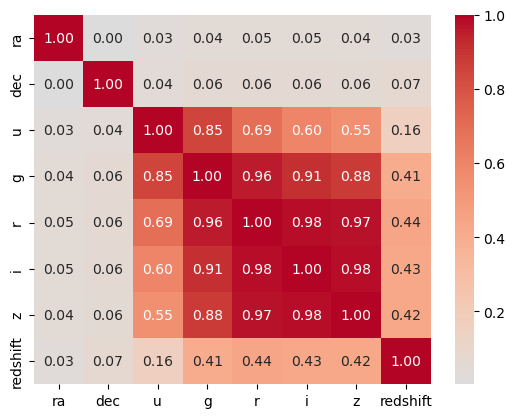

In [9]:
# use seaborn to plot the correlation matrix. Drop the 'class' column from the df before calculating the correlation matrix.
sns.heatmap(df.drop('class', axis=1).corr(), annot=True, center=0,cmap='coolwarm', fmt='.2f')

**Task: Reproduce the same plot for each of the three classes. (1 point)**
You can select the values from the pandas dataframe by selecting over the column 'class'. 

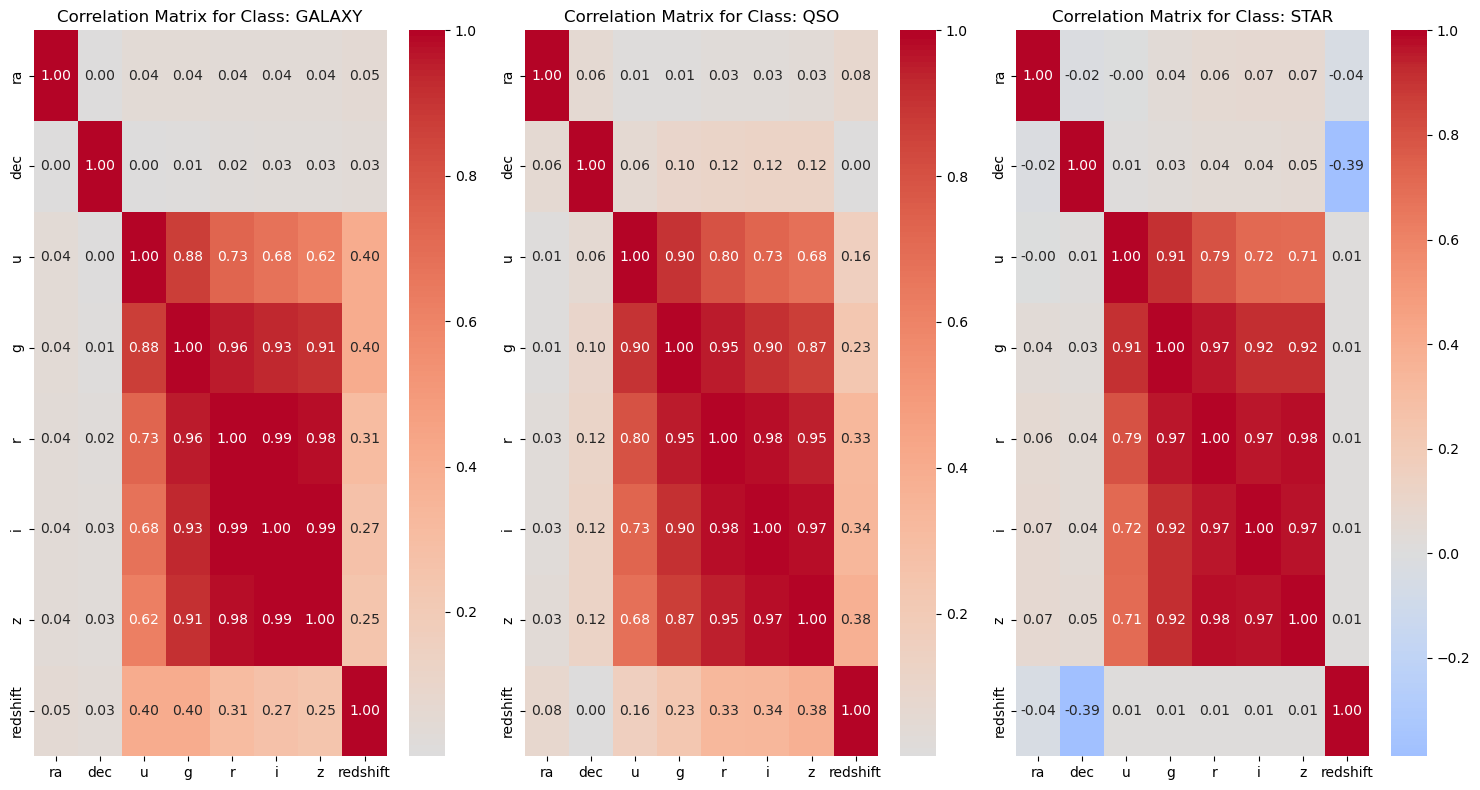

In [10]:
# Create a 3x1 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Loop through each class and plot the correlation matrix
for i, class_label in enumerate(le.classes_):
    class_df = df[df['class'] == i].drop('class', axis=1)
    sns.heatmap(class_df.corr(), annot=True, center=0, cmap='coolwarm', fmt='.2f', ax=axes[i])
    axes[i].set_title(f'Correlation Matrix for Class: {class_label}')

plt.tight_layout()
plt.show()

**Task: Can you comment on groups of observations that can be grouped together or that appear independent from each other given these correlations, and if there is any difference between the three celestial objects? (**1 point**)**

For all three classes, the r, i, and z bands all apear highly correlation. In Galaxy and Star groupings, this is consistenly higher than a correlation coefficent of 0.97. In The QSO band, this dips as low as .95. Regardless, it seems these three bands are consistently well correlated. The u band seems the most indepeendent, and the g band somewhere between the two.

Overall, the three sets of celestial objects do not stand out as very different on these surveys. All three some the same general pattern of correlation in the five bands. The one exception is that all five bands are somewhat correlated with redshift in Galaxy and QSO classes, but not in the Star class. However, the correlations are relatively weak, and I'm wary of reading too much into this.

### 1.5 Data exploration
Given the structure of the correlations, we will explore the values of the data.

#### 1.5.a. Distributions of redshift
"redshifting" happens when the source of light is becoming more distant to the receiver: the object is moving away from Earth. 

**Task: plot histograms for the 'redshift' feature column for each class (1 point).**

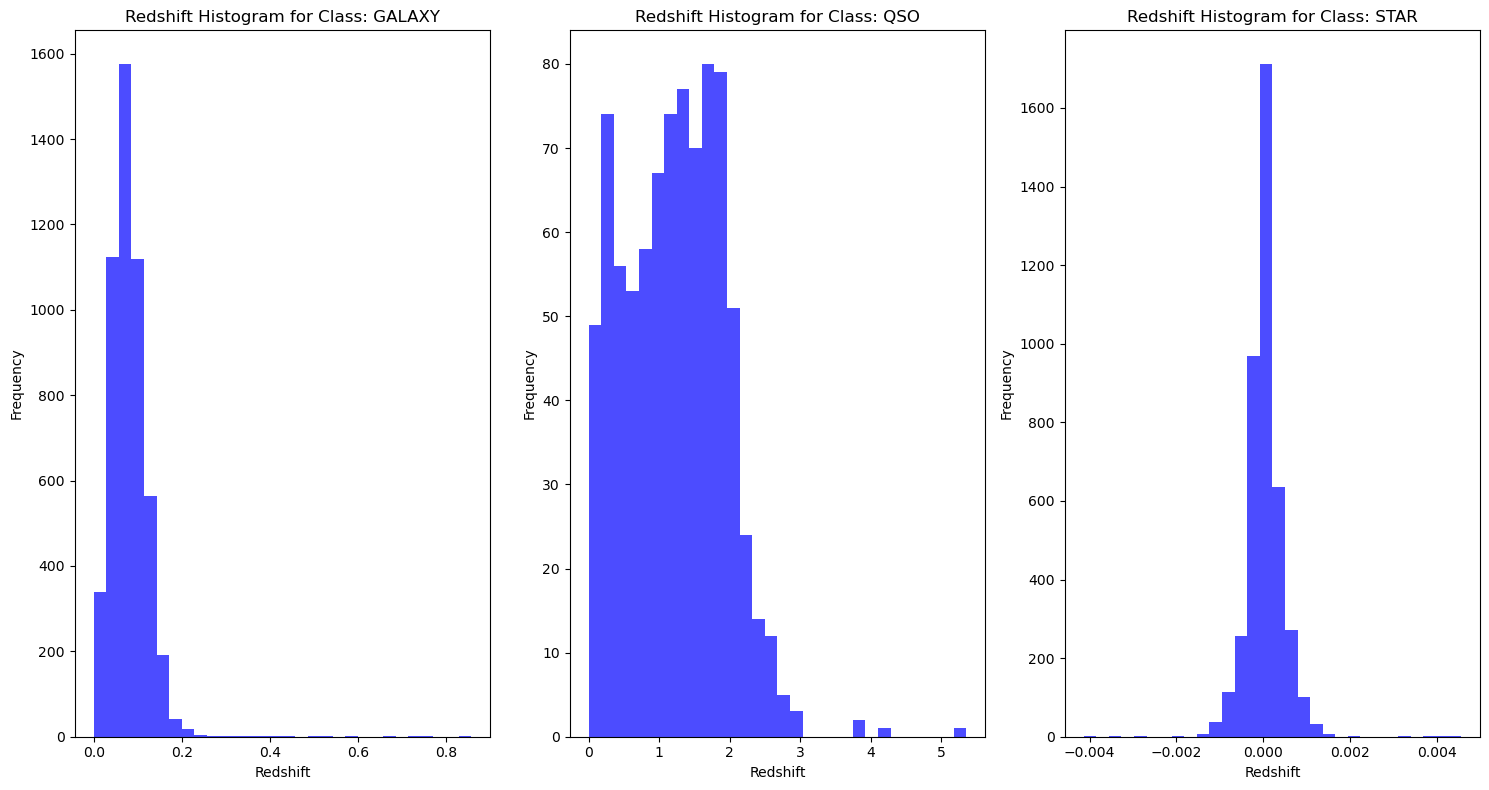

In [11]:
# plot histograms for the ‘redshift’ feature column for each class

# Create a 3x1 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Loop through each class and plot the histogram of the redshift column
for i, class_label in enumerate(le.classes_):
    class_df = df[df['class'] == i]
    axes[i].hist(class_df['redshift'], bins=30, alpha=0.7, color='blue')
    axes[i].set_title(f'Redshift Histogram for Class: {class_label}')
    axes[i].set_xlabel('Redshift')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Task : Describe briefly the difference between the three histograms. (0.5 point)**

<!-- # answer -->
* **Star:** The star redshift is clustered VERY close to zero, with the slight devations from zero observed being many orders of magnitude smaller in variation than the other two classes. There are some negative values visible (but again, of a very small magnitude). This seems to imply objects that are only moving slowly relative to earth. The distribution apears roughly normal.


* **Galaxy:** The galaxy class shows consistnely positive redshift,  but of a small maginitude (~0.1). This implies that the objects are consistently moving away from earth, but not as fast as the quasars. The distribution apears roughly normal.

* **QSO:** The quasar distribution is clearly not normal (although the total count is smaller, which may be the cause). The redshift is over an order of magnitude larger than the galaxy class, and consistently positive. This implies quasars are consistently moving rapidly away from earth relative to galaxies (and stars).



#### 1.5.b. Right ascension (ra) and declination (dec) 

We will now plot the right ascension versus the declination depending on the class. You can use the ``lmplot`` function in ``seaborn`` (https://seaborn.pydata.org/generated/seaborn.lmplot.html) to represent the sky view of these objects.

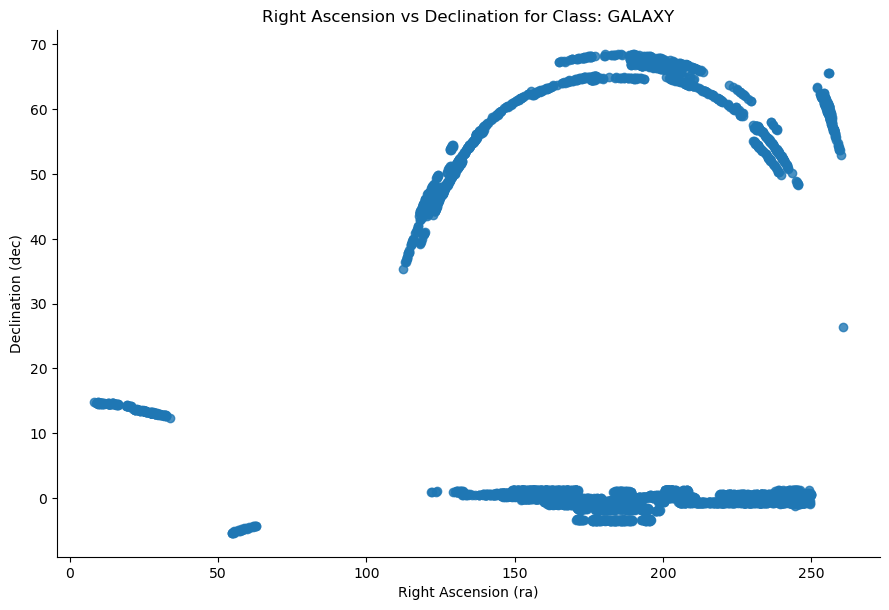

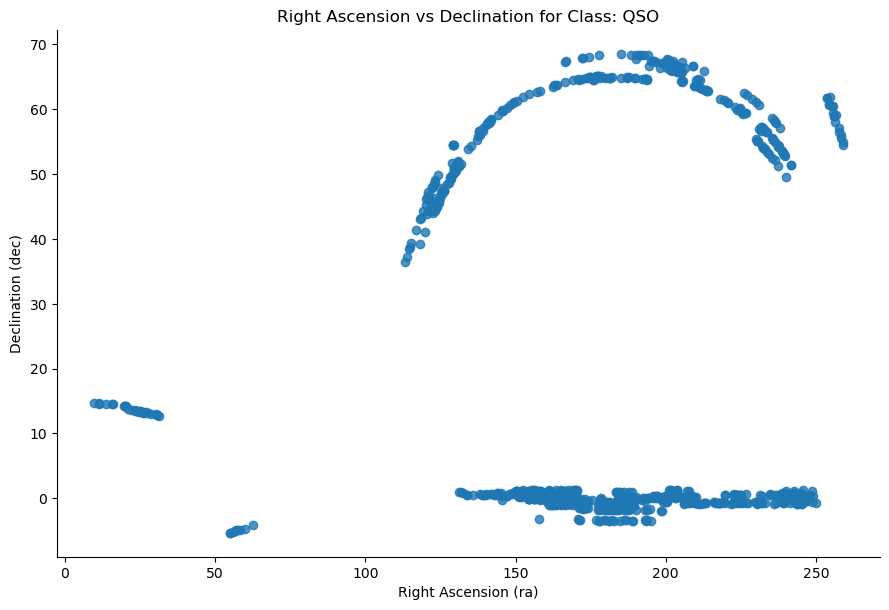

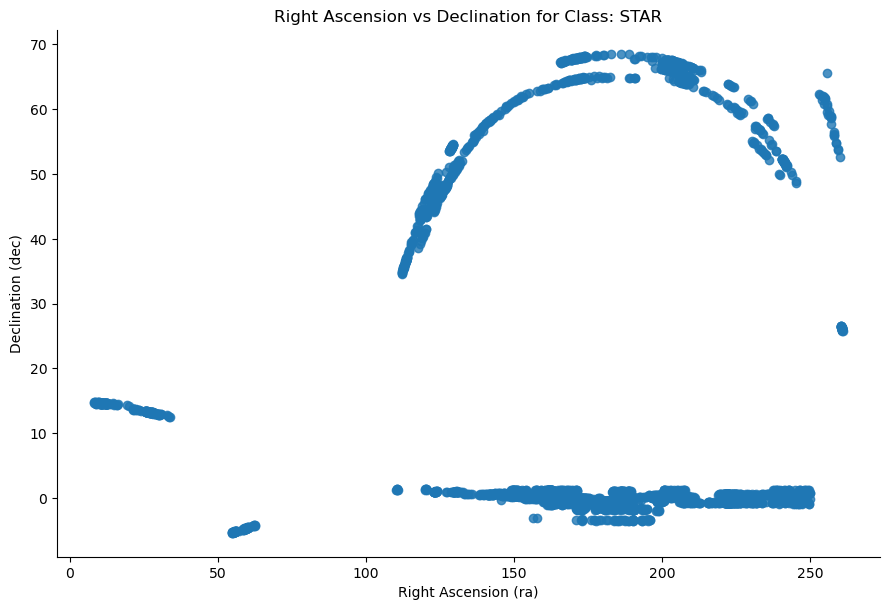

In [12]:
# Use seaborn's lmplot to plot right ascension vs declination for each class
for class_label in le.classes_:
    class_df = df[df['class'] == le.transform([class_label])[0]]
    sns.lmplot(x='ra', y='dec', data=class_df, fit_reg=False, height=6, aspect=1.5)
    plt.title(f'Right Ascension vs Declination for Class: {class_label}')
    plt.xlabel('Right Ascension (ra)')
    plt.ylabel('Declination (dec)')
    plt.show()


**Task: do you see any obvious differences such that one could easily discriminate between the two coordinates? (0.5 point)**

I'm a little unclear what is being asked here. If we are just trying to discriminate between the two coordinates, we could use the fact that declination is consistently between 0 and 90 degrees (70 in this dataset), while right ascension ranges from 0 to 360 degrees (max of ~260 in this dataset).

The distributions in the plots are not clearly different for the three sets of data. I don't think we could reliably use the location in the sky to discriminate between the diffreent classes.

#### 1.5.c Filters - u,g,r,i,z 

Recall: u, g, r, i, z represent the different wavelengths which are used to capture the observations. According to the correlation matrix, they are correlated for all three classes.

Therefore it is interesting to see that band 'u' is less correlated to the other bands. 

**Task Plot histograms and discuss why you expect these features to be correlated (1 points)**

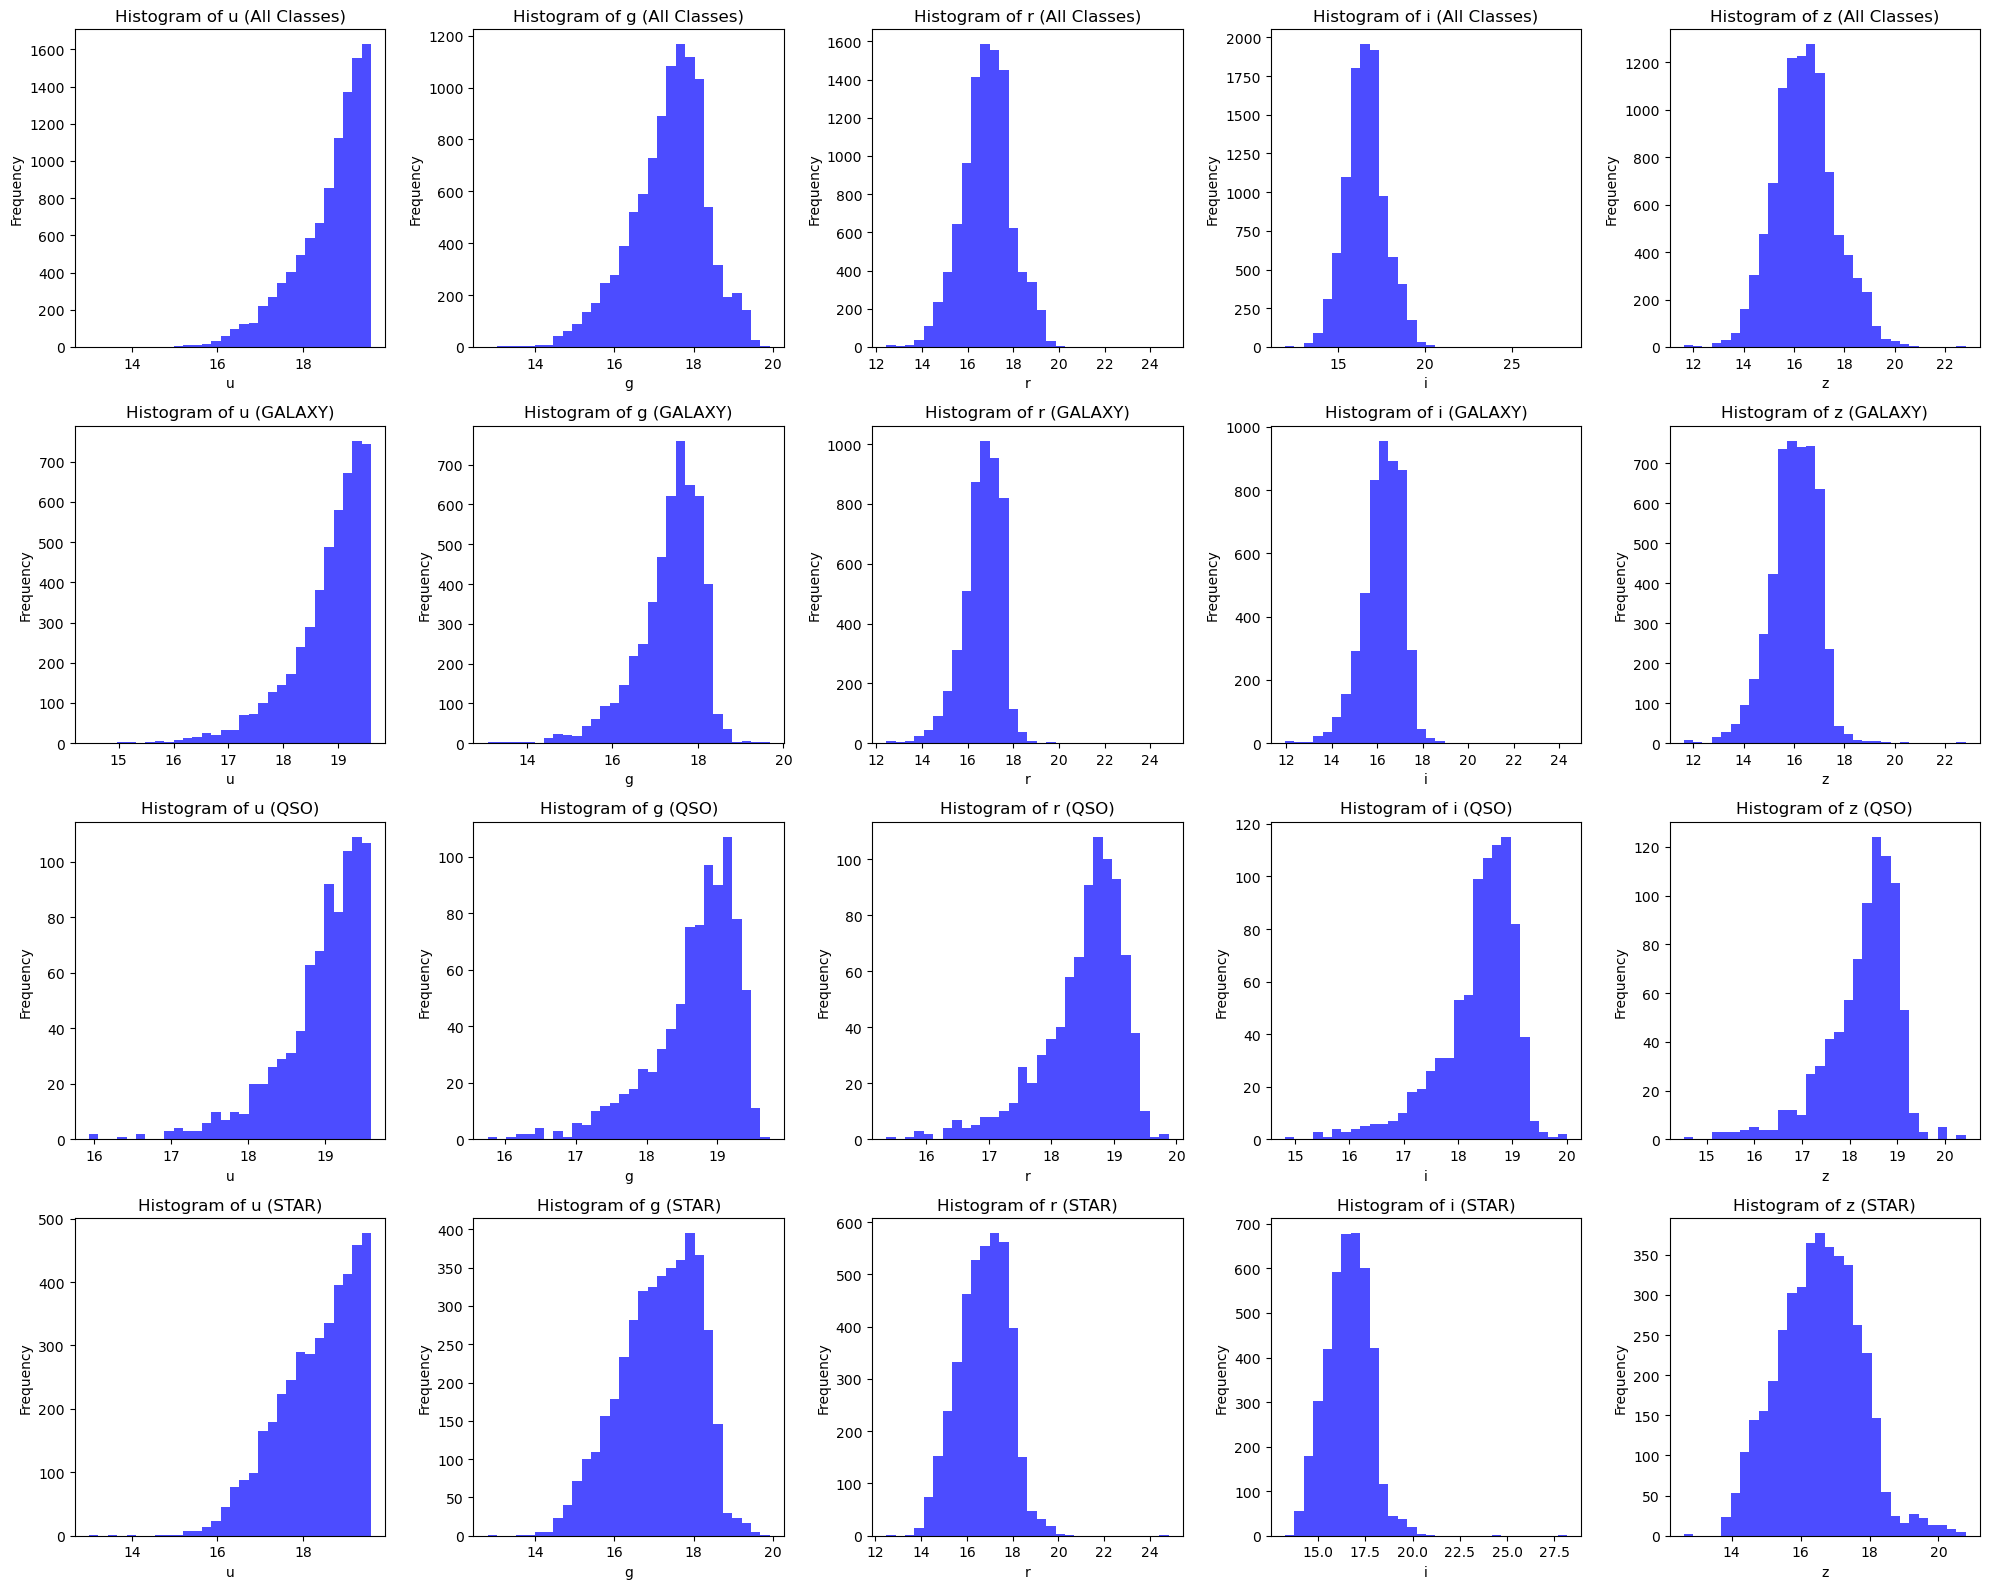

In [13]:
# Create a 4x5 subplot
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

# List of features to plot
features = ['u', 'g', 'r', 'i', 'z']

# Plot histograms for the entire dataset in the first row
for j, feature in enumerate(features):
    axes[0, j].hist(df[feature], bins=30, alpha=0.7, color='blue')
    axes[0, j].set_title(f'Histogram of {feature} (All Classes)')
    axes[0, j].set_xlabel(feature)
    axes[0, j].set_ylabel('Frequency')

# Plot histograms for each class in the next three rows
for i, class_label in enumerate(le.classes_):
    class_df = df[df['class'] == le.transform([class_label])[0]]
    for j, feature in enumerate(features):
        axes[i+1, j].hist(class_df[feature], bins=30, alpha=0.7, color='blue')
        axes[i+1, j].set_title(f'Histogram of {feature} ({class_label})')
        axes[i+1, j].set_xlabel(feature)
        axes[i+1, j].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Above I've plotted hisograms for the 5 different bands. I chose to plot a set for all the data, and then break it out by each class. I'm not fully sure that was neccesary, as I think my findings would be similar regardless. 

I see that the r, i, and z bands are all fairly normally distributed. The g band does have a longer tail on the low end, but it also apears to be somewhat normal in it's distribution. However, the u band is clearly NOT normally distributed, with the frequency of values increasing at higher values. Past the the maximum, most frequent value there are no additional measurements. Given this distribution, it's impossible that this non-normaly distributed u band would correlate as well as the other 4 more normally distributed bands.

<!-- Anwer: -->

### 1.6 Data Dimensionality Reduction
At this point, we are left with 8 features: redshift, u, g, r, i, z, ra, and dec. Among these, the filters (u, g, r, i, z) are correlated to each other. There is therefore a potential for reducing the dimensions of the features using PCA on these 5 features.

We will use the skilearn function ``sklearn.decomposition.PCA()`` to fit and transform the data into the PC coordinates. Lets' first explore how many PCs we need. Fit the PCA function over the total number of filters. You will fit the PCA function over an array with the columns selected from the dataframe. 

**Task: Perform the PCA over a max number of PCs, output the explained variance ratio values, decide on an appropriate maximum number of PC to use (6 points)**

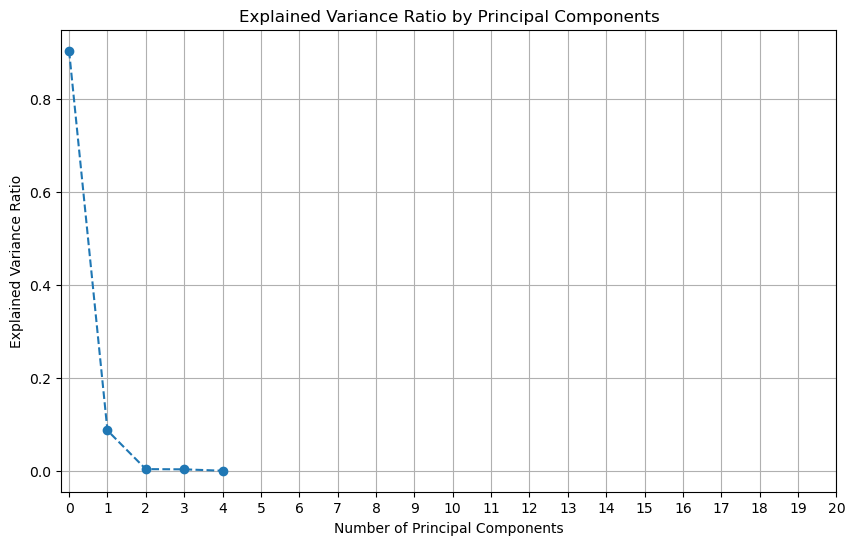

In [14]:
# Select the features for PCA
features = ['u', 'g', 'r', 'i', 'z']
X = df[features]

# Perform PCA with a large number of components
pca = PCA()
pca.fit(X)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(len(pca.explained_variance_ratio_)),pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(0, 21))
plt.grid()
plt.show()


In this analysis, it is clear that the vast majority of the explained varaince is in the first and seccond PC - by the 3rd PC, the explained variance is on the order of a couple percent. For that reason, I'll stick with 2 PCs to caputure the vast majority of the variance in these five bands.


We will now re-perform PCA with the number of PCs you found is most appropriate. Re-apply the fit-transform function. Update the dataframe by adding the PCA value(s) and dropping the columns of the 5 filter features.

**Task: PCA again, fit and transform, update the dataframe with the new feature(s) (3 points)**

In [15]:
# Perform PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a new DataFrame with the PCA components
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Add the PCA components to the original DataFrame and drop the original filter columns
df = df.join(df_pca)
df = df.drop(features, axis=1)

# Display the updated DataFrame
print(df.head())

           ra       dec  class  redshift       PC1       PC2
0  183.598370  0.135285      2 -0.000055 -0.195906  0.028545
1  183.680207  0.126185      0  0.123111  1.297480  0.590112
2  183.870529  0.049911      2 -0.000111 -1.446294 -0.566480
3  183.883288  0.102557      2  0.000590 -0.849479 -1.287360
4  183.847174  0.173694      2  0.000315  2.873346 -0.029723


## 2. Unsupervised Clustering with KMeans (20 points)

In this section, we will explore if the data features will be sufficient for classification. As a first exploration, we will perform unsupervised classification with Kmeans clustering.

## 2.1 Perform preliminary Kmeans (10 points)

Implement Kmeans here for a given number of clusters and on the features of interest. Choose 3 features.
* Use ``sklearn`` to perform Kmeans.
* Repeat Kmeans and discuss (in a markdown cell) the stability of clustering (e.g., use visualization to qualitatively assess the stability).


In [16]:
# Select the features for KMeans clustering
features_for_kmeans = ['redshift', 'PC1', 'PC2']
X_kmeans = df[features_for_kmeans]

# Perform KMeans clustering with 3 clusters a couple of times to see if the results are consistent
estimators = [
    ("k_means_run1", KMeans(n_clusters=3,random_state=42)),
    ("k_means_run2", KMeans(n_clusters=3,random_state=13)),
    ("k_means_bad_init", KMeans(n_clusters=3, init="random")),
]

# Loop through each estimator and plot the results
for name, est in estimators:

    est.fit(X_kmeans)
    labels = est.labels_

    # Plot
    fig = plt.figure(0, figsize=(4, 3))
    X_kmeans["clusterID"]=labels.astype('str')
    fig = px.scatter_3d(X_kmeans, x='PC1', y='PC2', z='redshift',color='clusterID')
    fig.show()


/var/folders/b3/ghp5pyzj7_x9mhrs3x202bm80000gn/T/ipykernel_6584/3426479641.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_kmeans["clusterID"]=labels.astype('str')


/var/folders/b3/ghp5pyzj7_x9mhrs3x202bm80000gn/T/ipykernel_6584/3426479641.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/var/folders/b3/ghp5pyzj7_x9mhrs3x202bm80000gn/T/ipykernel_6584/3426479641.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<Figure size 400x300 with 0 Axes>

The three plots all look fairly similar, and seem to have the data grouped in a reasonable way. They seem generally stable, with no clear changes between runs.



## 2.2 Find the optimal number of clusters (5 points)

Use a method to establish the optimal number of clusters.

I do this below using the elbow method. I test a range of numbers of clusters (2-31). For each number of clusters, I assess the intertia for 10 fits, and record the average intertia. Then I plot inertia as a function of the number of clusters.

In an ideal world, we would hope to see more of an inflection point where the inertia reaches a minimum. However, this is not the case. Even at the upper end of the number of clusters, we see a gradual decrease in inertia with increasing numbers of clusters. There is no clear number of clusters which minimizes the inertia. For that reason, I'm going to conclude that the k-means approach here isn't working well for us.

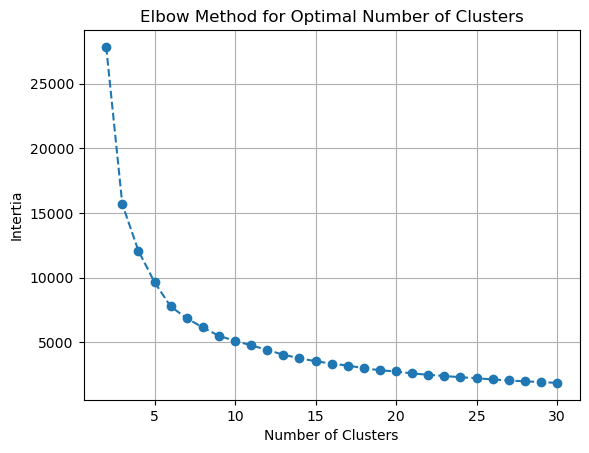

In [18]:
# Apply the elbow method to determine the optimal number of clusters

n_clusters = np.arange(2, 31)
intertia = []
distortion = []

for n in n_clusters:

    temp_intertia = []

    for i in range(10):
        kmeans = KMeans(n_clusters=n)
        kmeans.fit(X_kmeans)
        temp_intertia.append(kmeans.inertia_)
    
    intertia.append(np.mean(temp_intertia))

plt.plot(n_clusters, intertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Intertia')
plt.grid()


## 2.3 Discuss performance of clustering ( 5 points)

1. Perform silhouette analysis (silhouette visualization and score)

For n_clusters = 3 The average silhouette_score is : 0.4280831779253829


Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 3')

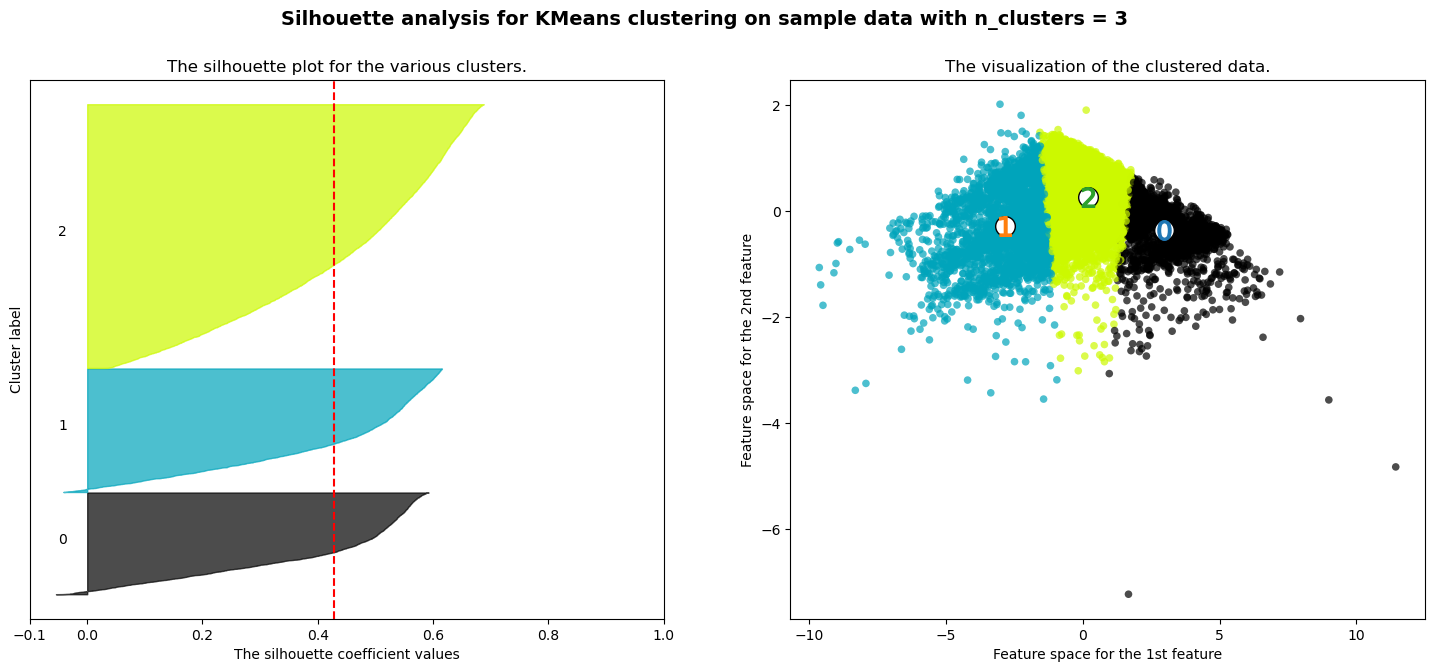

In [21]:
# pull out the appropriate columns (PC1, PC2, redshift) for the kmeans clustering and save as np array
X_kmeans = df[['PC1', 'PC2', 'redshift']].values

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

ncluster = 3

# Initialize the clusterer with n_clusters value and a random generator
# seed of 10 for reproducibility.
clusterer = KMeans(n_clusters=ncluster, random_state=10)
cluster_labels = clusterer.fit_predict(X_kmeans)

# The silhouette_score gives the average value for all the samples.
# This gives a perspective into the density and separation of the formed
# clusters
silhouette_avg = silhouette_score(X_kmeans, cluster_labels)
print(
    "For n_clusters =",
    ncluster,
    "The average silhouette_score is :",
    silhouette_avg,
)

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(X_kmeans, cluster_labels)

y_lower = 10
for i in range(ncluster):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / ncluster)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / ncluster)
ax2.scatter(
    X_kmeans[:, 0], X_kmeans[:, 1], marker="o", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)

# Labeling the clusters
centers = clusterer.cluster_centers_
# Draw white circles at cluster centers
ax2.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
)

for i, c in enumerate(centers):
    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=200, edgecolor=None)

ax2.set_title("The visualization of the clustered data.")
ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")

plt.suptitle(
    "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
    % ncluster,
    fontsize=14,
    fontweight="bold",
)

2. Calculate (python cell) and discuss (net markdown cell) homogeneity with respect to the ground truth labels using 3 appropriate metrics.

In [ ]:
# loop through estimators and print homogeneity, completeness, and v-measure

est = cluster_labels

hom_com_v = metrics.homogeneity_completeness_v_measure(df['class'], est.labels_)
print(f"Homogeneity: {hom_com_v[0]:.2f}")
print("Completeness: {hom_com_v[1]:.2f}")
print("V-Measure: {hom_com_v[2]:.2f}")

k_means_run1: Homogeneity: 0.16, Completeness: 0.14, V-Measure: 0.15
k_means_run2: Homogeneity: 0.16, Completeness: 0.14, V-Measure: 0.15
k_means_bad_init: Homogeneity: 0.16, Completeness: 0.14, V-Measure: 0.15


**Question:**
After performing KMeans clustering and calculating the completeness, homogeneity, and Fowlkes-Mallows scores, how can you determine if these scores are good? Compare the obtained scores to the ideal values and explain what each score indicates about the clustering quality. What do you find from your results?

## 3 Machine Learning Models (30 points)

We will now train different models on this dataset. We have a total of 8 features, 3 classes, and 10,000 samples. We will use K-Nearest Neighbors, Naive Bayes, Random Forest, Support Vector Machine, Multi Layer Perceptron.

We now follow a normal machine learning workflow:
* Feature scaling (3) points)
* Train/test set split (2 points)
* Model design, training, testing (15 points)
* Model comparisons, pick your winner, discuss feature importance using Random Forest. (10 points)

### 3.1 Feature Scaling
Scaling all values to be within the (0, 1) interval will reduce the distortion due to exceptionally high values and make some algorithms converge faster. You can scale the features only by dropping the "class" column without modifying the dataframe in place, using the pandas function ``drop()``.

**Task: Scale just the features (3 points)**

### 3.2 Test, train, validation data sets.
**Task: Split the data into a training and a test part.  (2 points)**

The models will be trained on the training data set and tested on the test data set

Computation time is important to account for when scaling up the data set and the model size. You can evaluate the relative computational time using the function ``time.perf_counter()`` to evaluate the absolute time. Then compare the computational time by making the difference between two time stamps:

``t1=time.perf_counter()``

``t2=time.perf_counter()``

``tcomp = t2 - t1``

We will also assess the model performance of these multi-class classifiers. We will evaluate the average of the scores over the 3 class labels.

In the following, we will be testing over several classifiers. Follow the steps:
1. model definition/design
2. training
3. prediction on test
4. evaluation: a) print the classification_report; b) save the precision, recall, fscore and accuracy in variables

### 3.3.a K Nearest Neighbors (3 points)
Check out the function arguments and definition here: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

### 3.3.b Naive Bayes (3 points)
Check out the sklearn tutorial pages here: https://scikit-learn.org/stable/modules/naive_bayes.html#naive-bayes. We propose to use the Gaussian Naive Bayes.

Naive Bayes assumes the data to be normally distributed which can be achieved by scaling using the MaxAbsScaler. For this example then we will use the unscaled data, then rescale it.

### 3.3.c Random Forest Classifier (2 points)
Check out the tutorial page here: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### 3.3.d Support Vector Machine Classifier (2 points)
Check out the sklearn information page here: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

### 3.3.e Multi-Layer Perceptron (3 points)

Check out the information page here: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

### 3.4 Model performance and comparison 

### 3.4.a Confusion Matrix and interpretation

**Task: Plot the confusion matrix (2 points)**

Use sklearn ``ConfusionMatrixDisplay" from the sklearn to visualize the confusion matrix

**Task: Comment on what you see the best classifier is likely to be (1 point).** You can also comment on the misclassification and confusion rates.

### 3.4.a K Fold Cross Validation
We will now perform k fold cross valdiation for the classifiers. We use the function ``cross_val_score`` on each ewstimator, on the training set, with 10 folds, and use accuracy as a score metric.

**Task: perform the cross validation over K folds, output the mean and standard deviation of the accuracy (3 points)**

**Task: Which method won the Xval test (1 point) ?**

see the cell below

<!-- answer here -->





### 3.4.c And the winner is ...

Let's compare the results. 
**Task: Create a pandas dataframe with all of the performance metrics, including the results from K-fold cross validation. (2 points)**

**Task: Comment on the accuracy and performance and choose a winner. (1 point)**

see the cell below

<!-- answer here -->






## 4 Summary (4 points)

### 4.1 Feature Importance using Random Forest Classifier

Decision Trees have the unique property of being able to order features by their ability to split between the classes. If some features dominate over other in the predictive power of classes, one can further reduce the dimension of the features for additional analysis. The vector of feature importance is the module ``rfc.feature_importances_``, sorted with ascending importance. Store the vector of importance .

**Task: plot a bar plot using the function ``matplotlib.pyplot.bar``. (2 points)**

**Task: What are the top three features (1 point)?**

enter in the cell below

<!-- answer -->

In this notebook, you have learned that redshift was the best predictor of what object you are observing. Now, did you actualy need to do this all to find this out? Probably not if you were an astrophysicist! But hey, we are not. So great job!

**Task: Briefly comment on what you have learned (1 point)**

see the cell below

<!-- answer -->